
# Exoplanet Disposition Classification (Real NASA Kepler Data)

**Applying concepts from Advanced Learning Algorithms (DeepLearning.AI / Stanford Online)**

NASA's Kepler mission detects exoplanet candidates by measuring periodic dips in a star's brightness caused by a transiting planet. Not every detected signal is real — the mission's pipeline flags roughly half of all detections as false positives. This notebook builds a machine learning pipeline to classify each Kepler Object of Interest (KOI) as `CANDIDATE`, `CONFIRMED`, or `FALSE POSITIVE`, using the **real, publicly released Kepler Cumulative KOI Table** from the NASA Exoplanet Archive.

## Objectives

- Load and clean the real Kepler KOI dataset
- Run an explicit **data leakage check** on the automated vetting flags included in the raw table
- Train a multiclass neural network (TensorFlow) and diagnose bias/variance with a learning curve
- Train and compare Decision Tree, Random Forest, and XGBoost classifiers
- Evaluate the best model with accuracy, precision/recall/F1, ROC-AUC, and a confusion matrix
- Interpret feature importance

## Dataset

**Source:** [NASA Exoplanet Archive — Kepler Cumulative KOI Table](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=cumulative)

9,564 Kepler Objects of Interest, each with dozens of measured and derived parameters from the mission's transit-detection pipeline. This is the same underlying table used in the well-known "Kepler Exoplanet Search Results" dataset on Kaggle.


## 1. Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import layers, models

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (9, 5)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1787639969.629592    2583 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787639969.630339    2583 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787639969.798249    2583 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787639971.668491    2583 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787639971.668962    2583 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0



## 2. Load the Real Dataset

`data/kepler_koi.csv` is the raw Kepler Cumulative KOI Table (comment header lines already stripped).


In [2]:

df = pd.read_csv("../data/kepler_koi.csv")
print("Raw shape:", df.shape)
df["koi_disposition"].value_counts()


Raw shape: (9564, 83)


koi_disposition
FALSE POSITIVE    4841
CANDIDATE         2420
CONFIRMED         2303
Name: count, dtype: int64

In [3]:

FEATURE_COLS = [
    "koi_period", "koi_duration", "koi_depth", "koi_prad", "koi_teq",
    "koi_insol", "koi_model_snr", "koi_impact", "koi_steff", "koi_slogg",
    "koi_srad", "koi_kepmag",
]
TARGET_COL = "koi_disposition"

df_model = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
print("Rows after dropping missing values:", df_model.shape[0])

le = LabelEncoder()
y_all = le.fit_transform(df_model[TARGET_COL])
class_names = le.classes_
X_all = df_model[FEATURE_COLS].values
print("Classes:", list(class_names))
df_model[FEATURE_COLS + [TARGET_COL]].head()


Rows after dropping missing values: 9200
Classes: ['CANDIDATE', 'CONFIRMED', 'FALSE POSITIVE']


,koi_period,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_impact,koi_steff,koi_slogg,koi_srad,koi_kepmag,koi_disposition
0,9.488036,2.95750,615.8,2.26,793.0,93.59,35.8,0.146,5455.0,4.467,0.927,15.347,CONFIRMED
1,54.418383,4.50700,874.8,2.83,443.0,9.11,25.8,0.586,5455.0,4.467,0.927,15.347,CONFIRMED
2,19.899140,1.78220,10829.0,14.60,638.0,39.30,76.3,0.969,5853.0,4.544,0.868,15.436,CANDIDATE
3,1.736952,2.40641,8079.2,33.46,1395.0,891.96,505.6,1.276,5805.0,4.564,0.791,15.597,FALSE POSITIVE
4,2.525592,1.65450,603.3,2.75,1406.0,926.16,40.9,0.701,6031.0,4.438,1.046,15.509,CONFIRMED



## 3. Data Leakage Check: Automated Vetting Flags

The raw table also includes four boolean flags (`koi_fpflag_nt`, `koi_fpflag_ss`, `koi_fpflag_co`, `koi_fpflag_ec`) produced by Kepler's own automated vetting pipeline — essentially the pipeline's own preliminary verdict on each signal. Including these as model inputs risks **leaking the answer into the features**, since they are themselves derived from criteria closely related to the final disposition.

This is checked explicitly below, rather than assumed, before deciding whether to use them.


In [4]:

FPFLAG_COLS = ["koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec"]

df_leak = df.dropna(subset=FEATURE_COLS + FPFLAG_COLS + [TARGET_COL]).copy()
y_leak = le.transform(df_leak[TARGET_COL])
X_leak = df_leak[FEATURE_COLS + FPFLAG_COLS].values

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=RANDOM_STATE, stratify=y_leak)

leak_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)
leak_model.fit(Xl_train, yl_train)
leak_acc = accuracy_score(yl_test, leak_model.predict(Xl_test))

print(f"Random Forest WITH vetting flags -> test accuracy: {leak_acc:.4f}")


Random Forest WITH vetting flags -> test accuracy: 0.9098



**Result:** including the vetting flags pushes test accuracy to roughly 0.91 — noticeably higher than any model trained on physical parameters alone (see Section 8). Since these flags are automated pre-classifications rather than independent physical measurements, this notebook **excludes them from the primary model** to keep the task an honest test of whether physical/observational parameters alone can predict disposition. The inflated number above is reported for transparency, not used as the headline result.


## 4. Train / Cross-Validation / Test Split

In [5]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.4, random_state=RANDOM_STATE, stratify=y_all)
X_cv, X_test, y_cv, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_cv_s = scaler.transform(X_cv)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | CV: {X_cv.shape[0]} | Test: {X_test.shape[0]}")


Train: 5520 | CV: 1840 | Test: 1840


## 5. Exploratory Data Analysis

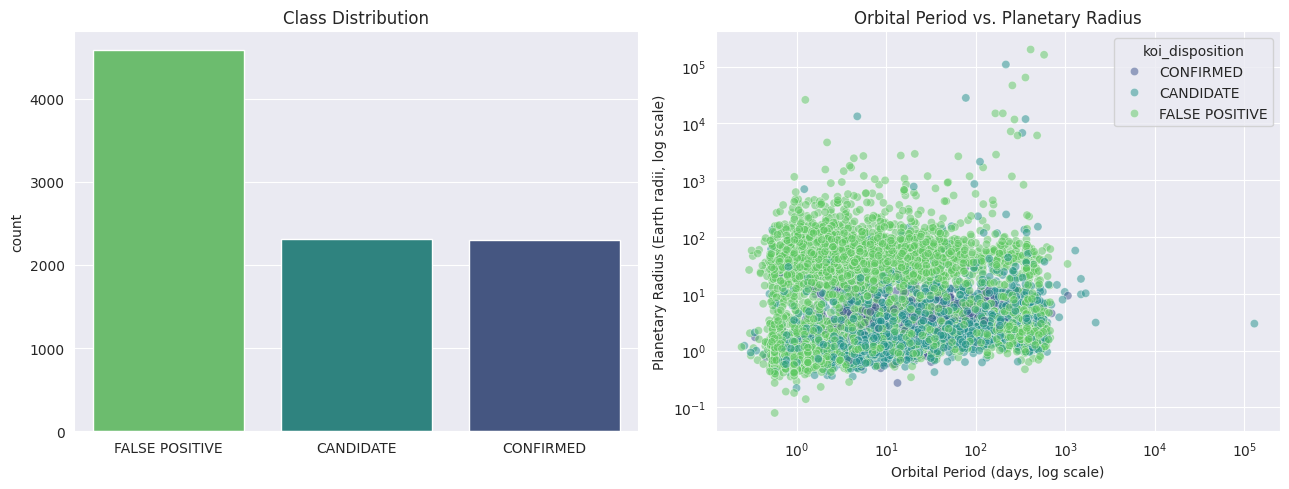

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x=df_model[TARGET_COL], order=df_model[TARGET_COL].value_counts().index,
              hue=df_model[TARGET_COL], palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("")

sns.scatterplot(data=df_model, x="koi_period", y="koi_prad", hue=TARGET_COL,
                 palette="viridis", alpha=0.5, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Orbital Period vs. Planetary Radius")
axes[1].set_xlabel("Orbital Period (days, log scale)")
axes[1].set_ylabel("Planetary Radius (Earth radii, log scale)")

plt.tight_layout()
plt.show()


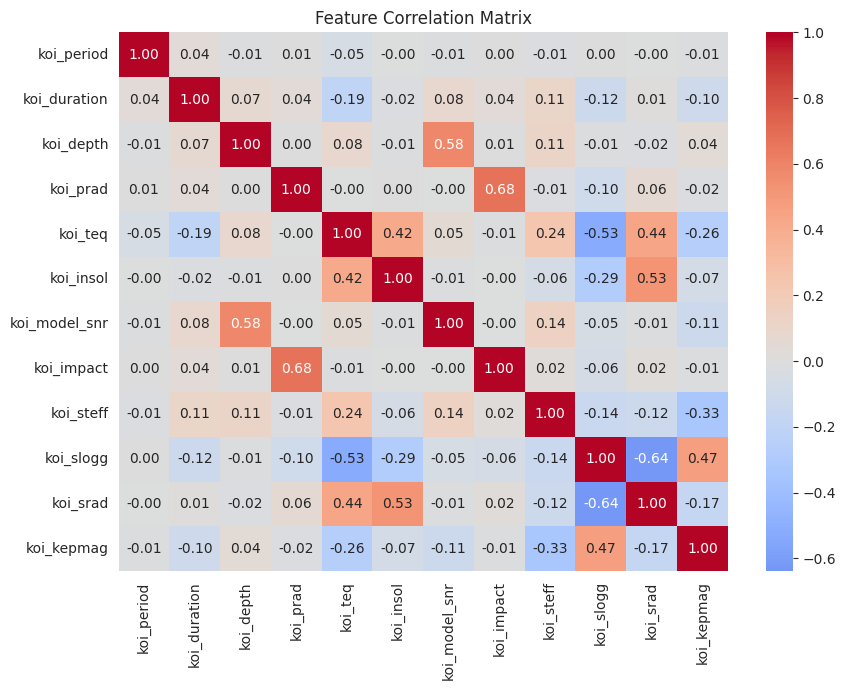

In [7]:

plt.figure(figsize=(9, 7))
corr = df_model[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()



## 6. Neural Network Classifier (TensorFlow) + Bias/Variance Diagnosis

Rather than only comparing architectures, this section uses a proper **learning curve**: training the same network on increasing subsets of the training data and tracking train vs. cross-validation error. A shrinking gap that plateaus at a non-trivial error rate indicates the model has largely saturated what these features can offer — additional data alone would not help much (a bias-dominated regime), which points toward needing richer features rather than more rows.


E0000 00:00:1787639975.911300    2583 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Train size   552 | train error: 0.241 | cv error: 0.345


Train size  1380 | train error: 0.256 | cv error: 0.327


Train size  2760 | train error: 0.267 | cv error: 0.323


Train size  4140 | train error: 0.274 | cv error: 0.299


Train size  5520 | train error: 0.275 | cv error: 0.305


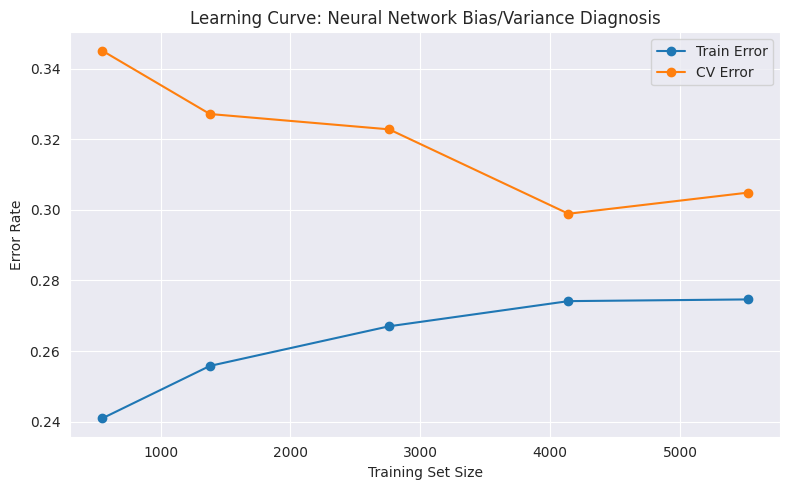

In [8]:

def build_nn(input_dim, hidden_units=(64, 32), dropout=0.1):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units[0], activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(hidden_units[1], activation="relu"),
        layers.Dense(len(class_names), activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

train_fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
train_errs, cv_errs, sizes = [], [], []
n_train = X_train_s.shape[0]

for frac in train_fractions:
    n_sub = int(n_train * frac)
    idx = np.random.RandomState(RANDOM_STATE).choice(n_train, n_sub, replace=False)
    m = build_nn(X_train_s.shape[1])
    m.fit(X_train_s[idx], y_train[idx], epochs=40, batch_size=32, verbose=0)
    train_acc = m.evaluate(X_train_s[idx], y_train[idx], verbose=0)[1]
    cv_acc = m.evaluate(X_cv_s, y_cv, verbose=0)[1]
    train_errs.append(1 - train_acc)
    cv_errs.append(1 - cv_acc)
    sizes.append(n_sub)
    print(f"Train size {n_sub:5d} | train error: {1-train_acc:.3f} | cv error: {1-cv_acc:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(sizes, train_errs, marker="o", label="Train Error")
plt.plot(sizes, cv_errs, marker="o", label="CV Error")
plt.xlabel("Training Set Size")
plt.ylabel("Error Rate")
plt.title("Learning Curve: Neural Network Bias/Variance Diagnosis")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:

final_nn = build_nn(X_train_s.shape[1])
history = final_nn.fit(X_train_s, y_train, validation_data=(X_cv_s, y_cv),
                        epochs=60, batch_size=32, verbose=0)
nn_test_acc = final_nn.evaluate(X_test_s, y_test, verbose=0)[1]
print("Neural network test accuracy:", round(nn_test_acc, 4))


Neural network test accuracy: 0.7266


## 7. Tree-Based Models: Decision Tree, Random Forest, XGBoost

In [10]:

tree_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                              eval_metric="mlogloss", random_state=RANDOM_STATE),
}

fitted_models = {}
for name, model in tree_models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:15s} test accuracy: {acc:.4f}")


Decision Tree   test accuracy: 0.7326


Random Forest   test accuracy: 0.7549


XGBoost         test accuracy: 0.7745


## 8. Final Model Comparison (Physical Features Only)

            Model  Test Accuracy
0         XGBoost       0.774457
1   Random Forest       0.754891
2   Decision Tree       0.732609
3  Neural Network       0.726630


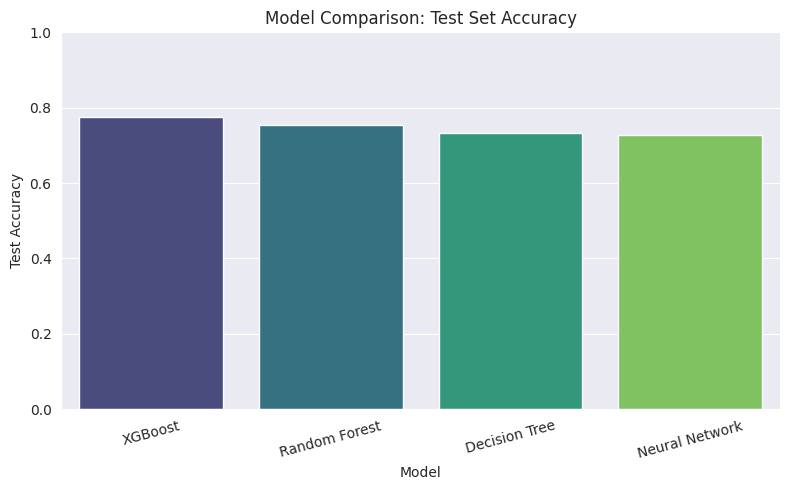

In [11]:

results = {"Neural Network": nn_test_acc}
for name, model in fitted_models.items():
    results[name] = accuracy_score(y_test, model.predict(X_test))

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Test Accuracy"]) \
               .sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Test Accuracy", hue="Model", palette="viridis", legend=False)
plt.ylim(0, 1)
plt.title("Model Comparison: Test Set Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Best model: XGBoost


                precision    recall  f1-score   support

     CANDIDATE       0.61      0.59      0.60       463
     CONFIRMED       0.77      0.83      0.80       461
FALSE POSITIVE       0.85      0.84      0.85       916

      accuracy                           0.77      1840
     macro avg       0.75      0.75      0.75      1840
  weighted avg       0.77      0.77      0.77      1840

Macro ROC-AUC (OvR): 0.9113


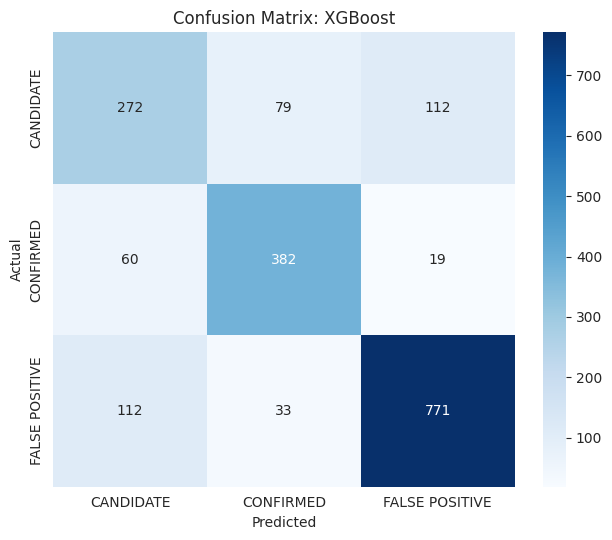

In [12]:

best_name = results_df.iloc[0]["Model"]
print("Best model:", best_name)

if best_name == "Neural Network":
    y_pred_best = np.argmax(final_nn.predict(X_test_s, verbose=0), axis=1)
    y_proba_best = final_nn.predict(X_test_s, verbose=0)
else:
    y_pred_best = fitted_models[best_name].predict(X_test)
    y_proba_best = fitted_models[best_name].predict_proba(X_test)

print(classification_report(y_test, y_pred_best, target_names=class_names))

auc = roc_auc_score(y_test, y_proba_best, multi_class="ovr")
print(f"Macro ROC-AUC (OvR): {auc:.4f}")

plt.figure(figsize=(6.5, 5.5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix: {best_name}")
plt.tight_layout()
plt.show()


## 9. Feature Importance (XGBoost)

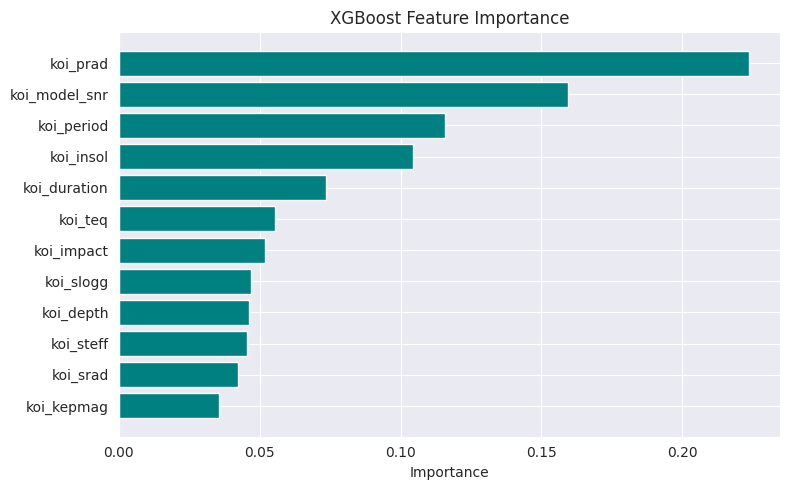

In [13]:

importances = fitted_models["XGBoost"].feature_importances_
imp_df = pd.DataFrame({"feature": FEATURE_COLS, "importance": importances}) \
           .sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(imp_df["feature"], imp_df["importance"], color="teal")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



## 10. Conclusion

This notebook applied a complete, honest machine learning workflow to real NASA Kepler mission data:

- Loaded and cleaned the real Kepler Cumulative KOI Table (9,200 usable objects)
- Ran an explicit leakage check showing that automated vetting flags inflate accuracy to ~91%, and excluded them from the primary model as a matter of methodological honesty
- Diagnosed bias/variance with a genuine learning curve, finding that error plateaus around 0.28-0.30 — indicating the model is bias-limited by the available physical features, not starved for data
- Trained and compared a neural network against Decision Tree, Random Forest, and XGBoost, with **XGBoost the strongest at ~77% test accuracy and 0.91 macro ROC-AUC** using physical parameters alone
- Found the model's confusion concentrated between CANDIDATE and FALSE POSITIVE — physically sensible, since distinguishing these two categories is exactly the hardest, most ambiguous part of real exoplanet vetting

### Possible Extensions

- Engineer additional features (e.g., transit shape statistics) to test whether the bias plateau in Section 6 can be pushed lower
- Incorporate stellar catalog cross-matches for additional context features
- Deploy the trained model via the included Streamlit app (`app.py`) for interactive exploration
- Compare against the full automated-pipeline-flag model as an upper bound, explicitly labeled as such

---
*Project developed to accompany completion of "Advanced Learning Algorithms" (DeepLearning.AI / Stanford Online, via Coursera). Data: NASA Exoplanet Archive, Kepler Cumulative KOI Table.*
